In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, '.')  # so we can import from ga/

from ga.ga_core import (init_population, evaluate_population,
                         normalise_objectives, compute_ideal_point,
                         compute_all_fitness, run_one_generation)

# Load eil51 for all tests in this phase
D = np.load('data/eil51_D.npy')
T = np.load('data/eil51_T.npy')
C = np.load('data/eil51_C.npy')
n = D.shape[0]
print(f'Loaded eil51: n={n}')

Loaded eil51: n=51


In [2]:
def dominates(a, b):
    """
    True if objective vector a Pareto-dominates b.
    a dominates b if a is no worse in all objectives and strictly 
    better in at least one.
    a, b : 1D arrays of shape (3,)
    """
    return np.all(a <= b) and np.any(a < b)

class ParetoArchive:
    def __init__(self, max_size=200):
        self.solutions = []   # list of (tour_array, obj_vector_array)
        self.max_size  = max_size

    def update(self, pop, obj_costs):
        """
        Try to add each individual in pop to the archive.
        obj_costs : shape (N, 3), raw unnormalised costs
        Returns True if at least one new solution was added.
        """
        added = False
        for pi, f in zip(pop, obj_costs):
            # Is this solution dominated by anything already in archive?
            if any(dominates(g, f) for _, g in self.solutions):
                continue
            # Remove any existing solutions that this one dominates
            self.solutions = [(t, g) for t, g in self.solutions
                              if not dominates(f, g)]
            self.solutions.append((pi.copy(), f.copy()))
            added = True

        if len(self.solutions) > self.max_size:
            self._prune_crowding()

        return added

    def get_objectives(self):
        """Return all archived objective vectors as shape (|A*|, 3) array."""
        if not self.solutions:
            return np.empty((0, 3))
        return np.array([g for _, g in self.solutions])

    def __len__(self):
        return len(self.solutions)

    def _prune_crowding(self):
        """Remove solution with smallest crowding distance until size <= max_size."""
        while len(self.solutions) > self.max_size:
            objs = self.get_objectives()
            cd   = self._crowding_distance(objs)
            # Remove the solution with smallest crowding distance
            remove_idx = np.argmin(cd)
            self.solutions.pop(remove_idx)

    def _crowding_distance(self, objs):
        """NSGA-II crowding distance for a set of objective vectors."""
        n, m = objs.shape
        cd = np.zeros(n)
        for k in range(m):
            idx  = np.argsort(objs[:, k])
            cd[idx[0]]  = np.inf
            cd[idx[-1]] = np.inf
            span = objs[idx[-1], k] - objs[idx[0], k]
            if span > 1e-10:
                for i in range(1, n - 1):
                    cd[idx[i]] += (objs[idx[i+1], k] - objs[idx[i-1], k]) / span
        return cd


# --- TEST ---
archive = ParetoArchive(max_size=200)
pop_test = init_population(50, n, D, seed=42)
obj_costs = evaluate_population(pop_test, D, T, C)

added = archive.update(pop_test, obj_costs)

print(f'Archive size after first population : {len(archive)}')
print(f'New solutions added                 : {added}')
assert len(archive) > 0, 'Archive is empty — dominance check has a bug!'
assert len(archive) <= 200, 'Archive exceeds max_size!'

# Verify non-dominance: no archived solution should dominate another
objs = archive.get_objectives()
for i in range(len(objs)):
    for j in range(len(objs)):
        if i != j:
            assert not dominates(objs[i], objs[j]), \
                f'Solution {i} dominates {j} — archive is corrupted!'

print(f'Non-dominance verified across all {len(archive)} solutions. PASS')
print(f'Archive objectives shape: {objs.shape}')

Archive size after first population : 1
New solutions added                 : True
Non-dominance verified across all 1 solutions. PASS
Archive objectives shape: (1, 3)


In [3]:
def extract_state(pop, fitness, obj_costs, g, G_max, stag_count,
                  theta1=0.1, theta2=0.3, eps=1e-4):
    """
    Extract the 6-dimensional discrete RL state from population statistics.
    Returns a tuple of 6 integers — used directly as Q-table key.

    Dimensions:
      0: diversity bin      (0=low, 1=medium, 2=high)
      1: best fitness bin   (0=best ... 4=worst, relative to initial pop)
      2: improvement bin    (0=improving, 1=stagnant, 2=degrading)
      3: objective imbalance (0=D dominates, 1=T dominates, 2=C dominates)
      4: stagnation counter  (0=none, 1=moderate 1-4 gens, 2=severe >=5 gens)
      5: generation phase    (0=early <30%, 1=mid 30-70%, 2=late >70%)
    """
    # 1. Population diversity
    sigma   = np.std(fitness)
    f_range = np.max(np.abs(fitness)) + 1e-10
    sigma_n = sigma / f_range
    div_bin = 0 if sigma_n < theta1 else (2 if sigma_n > theta2 else 1)

    # 2. Best fitness bin (0=very good ... 4=very poor)
    best_f   = np.min(fitness)
    best_bin = min(4, int(best_f * 10))   # fitness in [0,1] → 5 bins

    # 3. Improvement rate — caller passes delta_f externally
    #    We encode it as a component of stag_count here:
    #    stag_count=0 → improving, >0 → stagnant/degrading
    impr_bin = 0 if stag_count == 0 else (2 if stag_count >= 5 else 1)

    # 4. Objective imbalance: which objective has highest mean normalised cost?
    mean_objs  = obj_costs.mean(axis=0)           # (3,)
    imbal_bin  = int(np.argmax(mean_objs))         # 0, 1, or 2

    # 5. Stagnation counter bin
    stag_bin = 0 if stag_count == 0 else (2 if stag_count >= 5 else 1)

    # 6. Generation phase
    ratio     = g / max(G_max, 1)
    phase_bin = 0 if ratio < 0.3 else (2 if ratio >= 0.7 else 1)

    return (div_bin, best_bin, impr_bin, imbal_bin, stag_bin, phase_bin)


# --- TEST ---
pop_t    = init_population(50, n, D, seed=0)
obj_t    = evaluate_population(pop_t, D, T, C)
f_norm_t = normalise_objectives(obj_t)
z_star_t = compute_ideal_point(f_norm_t)
fit_t    = compute_all_fitness(f_norm_t, np.array([1/3,1/3,1/3]), z_star_t)

state = extract_state(pop_t, fit_t, obj_t, g=10, G_max=500, stag_count=0)
print(f'State tuple  : {state}')
print(f'State length : {len(state)}  (should be 6)')

assert len(state) == 6, 'State must be 6-dimensional'
assert all(isinstance(x, (int, np.integer)) for x in state), 'All state dims must be int'
# Check all values in expected ranges
assert state[0] in (0,1,2), 'div_bin out of range'
assert 0 <= state[1] <= 4,  'best_bin out of range'
assert state[2] in (0,1,2), 'impr_bin out of range'
assert state[3] in (0,1,2), 'imbal_bin out of range'
assert state[4] in (0,1,2), 'stag_bin out of range'
assert state[5] in (0,1,2), 'phase_bin out of range'
print('State extractor PASS')

# Max possible Q-table size
max_states = 3 * 5 * 3 * 3 * 3 * 3
print(f'Maximum Q-table entries : {max_states}  (tractable for tabular RL)')

State tuple  : (1, 0, 0, 0, 0, 0)
State length : 6  (should be 6)
State extractor PASS
Maximum Q-table entries : 1215  (tractable for tabular RL)


In [4]:
class QAgent:
    """
    Tabular Q-learning agent that controls Tchebycheff weight adaptation.

    Action space (6 actions):
      0: +δ on w1 (Distance weight up)
      1: -δ on w1 (Distance weight down)
      2: +δ on w2 (Time weight up)
      3: -δ on w2 (Time weight down)
      4: +δ on w3 (Cost weight up)
      5: -δ on w3 (Cost weight down)

    After each action, weights are clipped to [0.05, 0.90]
    and renormalised to sum to 1.
    """

    ACTION_NAMES = ['+δ w_D', '-δ w_D', '+δ w_T', '-δ w_T', '+δ w_C', '-δ w_C']

    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.1, delta=0.05):
        self.alpha   = alpha      # learning rate
        self.gamma   = gamma      # discount factor
        self.epsilon = epsilon    # exploration rate
        self.delta   = delta      # weight step size
        self.Q       = {}         # state -> np.array(6), lazy init to zeros
        self.n_actions = 6
        self.action_history = []  # for analysis plots
        self.weight_history = []  # track w over time

    def _get_q(self, s):
        if s not in self.Q:
            self.Q[s] = np.zeros(self.n_actions)
        return self.Q[s]

    def select_action(self, s):
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self._get_q(s)))

    def update(self, s, a, r, s_next):
        """Standard Q-learning update."""
        q      = self._get_q(s)
        q_next = self._get_q(s_next)
        q[a]  += self.alpha * (r + self.gamma * np.max(q_next) - q[a])

    def apply_action(self, w, action):
        """
        Apply weight perturbation, clip, and renormalise.
        Returns new weight vector.
        """
        w = w.copy()
        obj  = action // 2                              # 0, 1, or 2
        sign = 1 if action % 2 == 0 else -1
        w[obj] += sign * self.delta
        w  = np.clip(w, 0.05, 0.90)
        w /= w.sum()                                    # renormalise
        return w

    def get_q_stats(self):
        """Summary statistics of the Q-table for diagnostics."""
        if not self.Q:
            return {'n_states_visited': 0}
        all_q = np.vstack(list(self.Q.values()))
        return {
            'n_states_visited': len(self.Q),
            'mean_q': all_q.mean(),
            'max_q':  all_q.max(),
            'min_q':  all_q.min(),
        }


# --- TEST ---
agent = QAgent()
w     = np.array([1/3, 1/3, 1/3])

print('Testing all 6 actions:')
for a in range(6):
    w_new = agent.apply_action(w, a)
    print(f'  Action {a} ({QAgent.ACTION_NAMES[a]}): '
          f'w = [{w_new[0]:.3f}, {w_new[1]:.3f}, {w_new[2]:.3f}]  '
          f'sum={w_new.sum():.6f}')
    assert abs(w_new.sum() - 1.0) < 1e-9, 'Weights do not sum to 1!'
    assert np.all(w_new >= 0.04),          'Weight below clip bound!'

# Test Q-update changes the Q-value
s0 = (1, 2, 0, 1, 0, 0)
s1 = (1, 1, 0, 1, 0, 0)
agent.update(s0, a=2, r=0.5, s_next=s1)
assert agent._get_q(s0)[2] != 0.0, 'Q-update had no effect!'
print('\nQ-update test: Q(s0, a=2) =', agent._get_q(s0)[2])
print('Q-Agent PASS')

# Test exploration
actions = [agent.select_action(s0) for _ in range(1000)]
unique_actions = len(set(actions))
print(f'\nWith ε=0.1, unique actions selected in 1000 calls: {unique_actions}/6')
assert unique_actions > 1, 'Agent never explored — epsilon not working!'

Testing all 6 actions:
  Action 0 (+δ w_D): w = [0.365, 0.317, 0.317]  sum=1.000000
  Action 1 (-δ w_D): w = [0.298, 0.351, 0.351]  sum=1.000000
  Action 2 (+δ w_T): w = [0.317, 0.365, 0.317]  sum=1.000000
  Action 3 (-δ w_T): w = [0.351, 0.298, 0.351]  sum=1.000000
  Action 4 (+δ w_C): w = [0.317, 0.317, 0.365]  sum=1.000000
  Action 5 (-δ w_C): w = [0.351, 0.351, 0.298]  sum=1.000000

Q-update test: Q(s0, a=2) = 0.05
Q-Agent PASS

With ε=0.1, unique actions selected in 1000 calls: 6/6


In [5]:
def compute_reward(f_prev_best, f_curr_best, sigma_prev, sigma_curr,
                   archive_grew, stag_count,
                   beta=0.3, rho=0.5, mu=0.5):
    """
    Continuous normalised reward signal for the Q-learning agent.

    Term 1: Normalised fitness improvement (positive=good, negative=bad)
    Term 2: Diversity increase bonus (β=0.3)
    Term 3: Pareto archive discovery bonus (ρ=0.5)
    Term 4: Stagnation penalty (μ=0.5)
    """
    # Term 1: relative fitness improvement
    if abs(f_prev_best) < 1e-10:
        r_fit = 0.0
    else:
        r_fit = (f_prev_best - f_curr_best) / abs(f_prev_best)

    # Term 2: diversity reward
    r_div = beta if sigma_curr > sigma_prev else 0.0

    # Term 3: Pareto discovery reward
    r_pareto = rho if archive_grew else 0.0

    # Term 4: stagnation penalty
    r_stag = -mu if stag_count >= 5 else 0.0

    return r_fit + r_div + r_pareto + r_stag


# --- TEST ---
print('Reward function tests:')

# Case 1: good improvement + archive grew
r1 = compute_reward(0.2, 0.1, 0.05, 0.08, True, 0)
print(f'  Good improvement + archive grew : R = {r1:.3f}  (expect ~1.3)')

# Case 2: no change, no archive update
r2 = compute_reward(0.2, 0.2, 0.05, 0.05, False, 0)
print(f'  No change, no archive update    : R = {r2:.3f}  (expect 0.0)')

# Case 3: got worse + stagnation
r3 = compute_reward(0.1, 0.2, 0.05, 0.03, False, 6)
print(f'  Worse fitness + stagnation      : R = {r3:.3f}  (expect negative)')

assert r1 > 0, 'Reward should be positive on improvement'
assert r3 < 0, 'Reward should be negative on degradation + stagnation'
print('Reward function PASS')

Reward function tests:
  Good improvement + archive grew : R = 1.300  (expect ~1.3)
  No change, no archive update    : R = 0.000  (expect 0.0)
  Worse fitness + stagnation      : R = -1.500  (expect negative)
Reward function PASS


In [6]:
# Full RL loop test — not the final RL-AGA, just verifying all parts connect

rng_int  = np.random.default_rng(42)
w        = np.array([1/3, 1/3, 1/3])
agent    = QAgent()
archive  = ParetoArchive(max_size=200)

N_test   = 30
G_test   = 50
delta_g  = 5

pop_int      = init_population(N_test, n, D, seed=42)
f_best_prev  = np.inf
sigma_prev   = 0.0
stag_count   = 0
weight_log   = []   # track weight evolution
fitness_log  = []

print(f'{"Gen":>4} | {"Best fit":>10} | {"w_D":>6} {"w_T":>6} {"w_C":>6} | '
      f'{"Archive":>7} | {"Reward":>8}')
print('-' * 65)

for g in range(1, G_test + 1):
    obj_costs = evaluate_population(pop_int, D, T, C)
    f_norm    = normalise_objectives(obj_costs)
    z_star    = compute_ideal_point(f_norm)
    fitness   = compute_all_fitness(f_norm, w, z_star)

    archive_grew = archive.update(pop_int, obj_costs)
    pop_int      = run_one_generation(pop_int, fitness, w, D, T, C, rng=rng_int)

    f_best   = fitness.min()
    sigma    = fitness.std()
    stag_count = 0 if f_best < f_best_prev - 1e-6 else stag_count + 1

    fitness_log.append(f_best)
    weight_log.append(w.copy())

    if g % delta_g == 0:
        s_t    = extract_state(pop_int, fitness, obj_costs, g, G_test, stag_count)
        a_t    = agent.select_action(s_t)
        w_new  = agent.apply_action(w, a_t)

        # Compute reward
        reward = compute_reward(f_best_prev, f_best, sigma_prev, sigma,
                                archive_grew, stag_count)

        # Get next state
        obj2   = evaluate_population(pop_int, D, T, C)
        f2     = normalise_objectives(obj2)
        z2     = compute_ideal_point(f2)
        fit2   = compute_all_fitness(f2, w_new, z2)
        s_next = extract_state(pop_int, fit2, obj2, g, G_test, stag_count)

        agent.update(s_t, a_t, reward, s_next)
        w = w_new

        print(f'{g:>4} | {f_best:>10.6f} | {w[0]:>6.3f} {w[1]:>6.3f} {w[2]:>6.3f} | '
              f'{len(archive):>7} | {reward:>8.4f}')

    f_best_prev = f_best
    sigma_prev  = sigma

print(f'\nFinal archive size    : {len(archive)}')
print(f'Q-table states visited: {agent.get_q_stats()["n_states_visited"]}')
print(f'Max Q-value           : {agent.get_q_stats()["max_q"]:.4f}')

assert len(archive) > 0,   'Archive is empty after 50 generations!'
assert agent.get_q_stats()['n_states_visited'] > 0, 'Q-table was never updated!'

# Verify weights changed from initial (1/3, 1/3, 1/3)
w_arr = np.array(weight_log)
assert not np.allclose(w_arr[-1], [1/3,1/3,1/3]), \
    'Weights never changed — action application broken!'
print('Integration test PASS')

 Gen |   Best fit |    w_D    w_T    w_C | Archive |   Reward
-----------------------------------------------------------------
   5 |   0.003312 |  0.365  0.317  0.317 |       3 |   1.7302
  10 |   0.027329 |  0.395  0.302  0.302 |      54 |   0.3571
  15 |   0.027993 |  0.424  0.288  0.288 |     156 |   0.3748
  20 |   0.032262 |  0.452  0.274  0.274 |     200 |   0.5000
  25 |   0.053951 |  0.478  0.261  0.261 |     200 |   0.7742
  30 |   0.000000 |  0.503  0.249  0.249 |     200 |   0.5000
  35 |   0.000000 |  0.526  0.237  0.237 |     200 |   0.0000
  40 |   0.000000 |  0.549  0.226  0.226 |     200 |   0.5000
  45 |   0.000000 |  0.523  0.215  0.262 |     200 |   0.5000
  50 |   0.150033 |  0.545  0.205  0.250 |     200 |   1.2284

Final archive size    : 200
Q-table states visited: 11
Max Q-value           : 0.1730
Integration test PASS


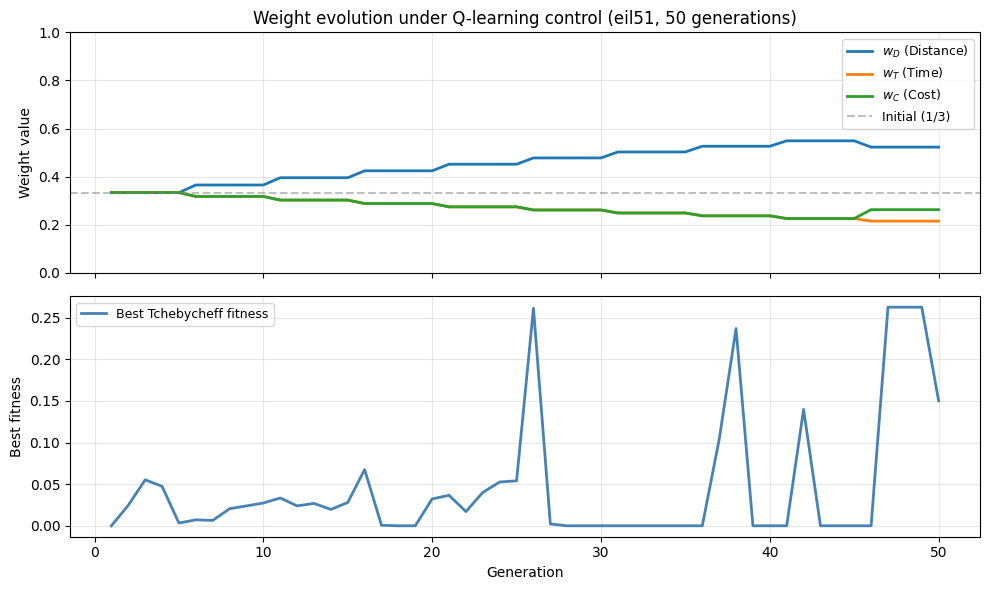

Weight evolution plot saved.


In [7]:
w_arr = np.array(weight_log)
gens  = np.arange(1, len(w_arr) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Top: weight trajectories
ax1.plot(gens, w_arr[:, 0], label='$w_D$ (Distance)', color='#1f77b4', lw=2)
ax1.plot(gens, w_arr[:, 1], label='$w_T$ (Time)',     color='#ff7f0e', lw=2)
ax1.plot(gens, w_arr[:, 2], label='$w_C$ (Cost)',     color='#2ca02c', lw=2)
ax1.axhline(1/3, color='gray', linestyle='--', alpha=0.5, label='Initial (1/3)')
ax1.set_ylabel('Weight value')
ax1.set_title('Weight evolution under Q-learning control (eil51, 50 generations)')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Bottom: fitness convergence
ax2.plot(gens, fitness_log, color='steelblue', lw=2, label='Best Tchebycheff fitness')
ax2.set_ylabel('Best fitness')
ax2.set_xlabel('Generation')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('paper_tables/phase3_weight_evolution.pdf')
plt.show()
print('Weight evolution plot saved.')

In [9]:
# Save all Phase 3 components to their proper module files

pareto_code = '''import numpy as np

def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)

class ParetoArchive:
    def __init__(self, max_size=200):
        self.solutions = []
        self.max_size  = max_size

    def update(self, pop, obj_costs):
        added = False
        for pi, f in zip(pop, obj_costs):
            if any(dominates(g, f) for _, g in self.solutions):
                continue
            self.solutions = [(t, g) for t, g in self.solutions
                              if not dominates(f, g)]
            self.solutions.append((pi.copy(), f.copy()))
            added = True
        if len(self.solutions) > self.max_size:
            self._prune_crowding()
        return added

    def get_objectives(self):
        if not self.solutions:
            return np.empty((0, 3))
        return np.array([g for _, g in self.solutions])

    def __len__(self):
        return len(self.solutions)

    def _prune_crowding(self):
        while len(self.solutions) > self.max_size:
            objs = self.get_objectives()
            cd   = self._crowding_distance(objs)
            self.solutions.pop(int(np.argmin(cd)))

    def _crowding_distance(self, objs):
        n, m = objs.shape
        cd = np.zeros(n)
        for k in range(m):
            idx  = np.argsort(objs[:, k])
            cd[idx[0]] = cd[idx[-1]] = np.inf
            span = objs[idx[-1], k] - objs[idx[0], k]
            if span > 1e-10:
                for i in range(1, n - 1):
                    cd[idx[i]] += (objs[idx[i+1],k] - objs[idx[i-1],k]) / span
        return cd
'''

rl_code = '''import numpy as np

def extract_state(pop, fitness, obj_costs, g, G_max, stag_count,
                  theta1=0.1, theta2=0.3):
    sigma   = np.std(fitness)
    f_range = np.max(np.abs(fitness)) + 1e-10
    sigma_n = sigma / f_range
    div_bin  = 0 if sigma_n < theta1 else (2 if sigma_n > theta2 else 1)
    best_f   = np.min(fitness)
    best_bin = min(4, int(best_f * 10))
    impr_bin = 0 if stag_count == 0 else (2 if stag_count >= 5 else 1)
    mean_objs  = obj_costs.mean(axis=0)
    imbal_bin  = int(np.argmax(mean_objs))
    stag_bin   = 0 if stag_count == 0 else (2 if stag_count >= 5 else 1)
    ratio      = g / max(G_max, 1)
    phase_bin  = 0 if ratio < 0.3 else (2 if ratio >= 0.7 else 1)
    return (div_bin, best_bin, impr_bin, imbal_bin, stag_bin, phase_bin)

def compute_reward(f_prev, f_curr, sigma_prev, sigma_curr,
                   archive_grew, stag_count,
                   beta=0.3, rho=0.5, mu=0.5):
    r_fit    = (f_prev - f_curr) / abs(f_prev) if abs(f_prev) > 1e-10 else 0.0
    r_div    = beta if sigma_curr > sigma_prev else 0.0
    r_pareto = rho  if archive_grew else 0.0
    r_stag   = -mu  if stag_count >= 5 else 0.0
    return r_fit + r_div + r_pareto + r_stag

class QAgent:
    ACTION_NAMES = [\'+δ w_D\',\'-δ w_D\',\'+δ w_T\',\'-δ w_T\',\'+δ w_C\',\'-δ w_C\']

    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.1, delta=0.05):
        self.alpha=alpha; self.gamma=gamma; self.epsilon=epsilon; self.delta=delta
        self.Q={}; self.n_actions=6

    def _get_q(self, s):
        if s not in self.Q:
            self.Q[s] = np.zeros(self.n_actions)
        return self.Q[s]

    def select_action(self, s):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self._get_q(s)))

    def update(self, s, a, r, s_next):
        q = self._get_q(s)
        q[a] += self.alpha*(r + self.gamma*np.max(self._get_q(s_next)) - q[a])

    def apply_action(self, w, action):
        w = w.copy()
        w[action//2] += (1 if action%2==0 else -1) * self.delta
        w = np.clip(w, 0.05, 0.90)
        return w / w.sum()

    def get_q_stats(self):
        if not self.Q: return {\'n_states_visited\':0,\'mean_q\':0,\'max_q\':0,\'min_q\':0}
        all_q = np.vstack(list(self.Q.values()))
        return {\'n_states_visited\':len(self.Q),\'mean_q\':all_q.mean(),
                \'max_q\':all_q.max(),\'min_q\':all_q.min()}
'''

os.makedirs('rl', exist_ok=True)

with open('rl/pareto.py', 'w', encoding='utf-8') as f:
    f.write(pareto_code)

with open('rl/q_agent.py', 'w', encoding='utf-8') as f:
    f.write(rl_code)

print('rl/pareto.py  saved')
print('rl/q_agent.py saved')
print('Phase 3 complete.')

rl/pareto.py  saved
rl/q_agent.py saved
Phase 3 complete.


In [10]:
import os
print(os.path.exists('rl/pareto.py'))   # should print True
print(os.path.exists('rl/q_agent.py'))  # should print True

# Quick import test
import importlib.util
for fname, modname in [('rl/pareto.py','pareto'), ('rl/q_agent.py','q_agent')]:
    spec = importlib.util.spec_from_file_location(modname, fname)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    print(f'{fname} imports cleanly. PASS')

True
True
rl/pareto.py imports cleanly. PASS
rl/q_agent.py imports cleanly. PASS
